In [1]:
!pip install -q datascience
!pip install -q pandas-profiling
!pip install -q yellowbrick

In [2]:
!pip install --q --upgrade pandas-profiling
!pip install -q --upgrade yellowbrick

## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint

## Data Acqisition

In [5]:
data= pd.read_csv(filepath_or_buffer = 'carprice.csv')
data.shape

(205, 26)

In [6]:
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
'''
{symboling : string}
'''

'\n{symboling : string}\n'

In [9]:
data.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [10]:
data.skew()

C:\Users\admin\AppData\Local\Temp\ipykernel_5708\1188251951.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  data.skew()


car_ID              0.000000
symboling           0.211072
wheelbase           1.050214
carlength           0.155954
carwidth            0.904003
carheight           0.063123
curbweight          0.681398
enginesize          1.947655
boreratio           0.020156
stroke             -0.689705
compressionratio    2.610862
horsepower          1.405310
peakrpm             0.075159
citympg             0.663704
highwaympg          0.539997
price               1.777678
dtype: float64

## EDA

In [11]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [12]:
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


what is the fuel type distribution:

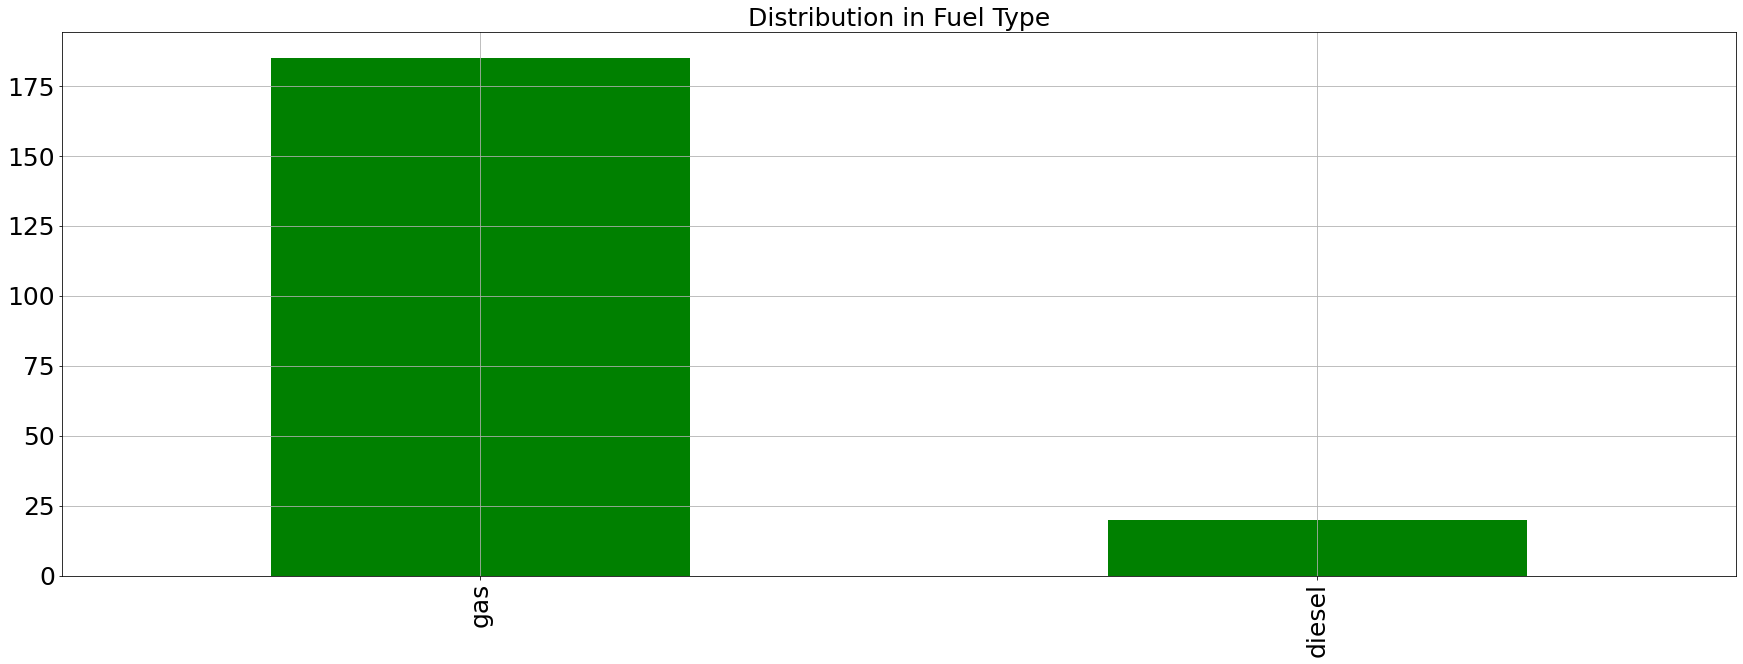

In [13]:
paper = plt.figure(figsize=[30,10])
data['fueltype'].value_counts().plot.bar(color="green")
plt.xticks(size=25)
plt.yticks(size=25)
plt.title(label="Distribution in Fuel Type",size=25)
plt.grid(visible=True)
plt.show()

In [14]:
data['fueltype'].value_counts()

gas       185
diesel     20
Name: fueltype, dtype: int64

In [15]:
data['doornumber'].value_counts()

four    115
two      90
Name: doornumber, dtype: int64

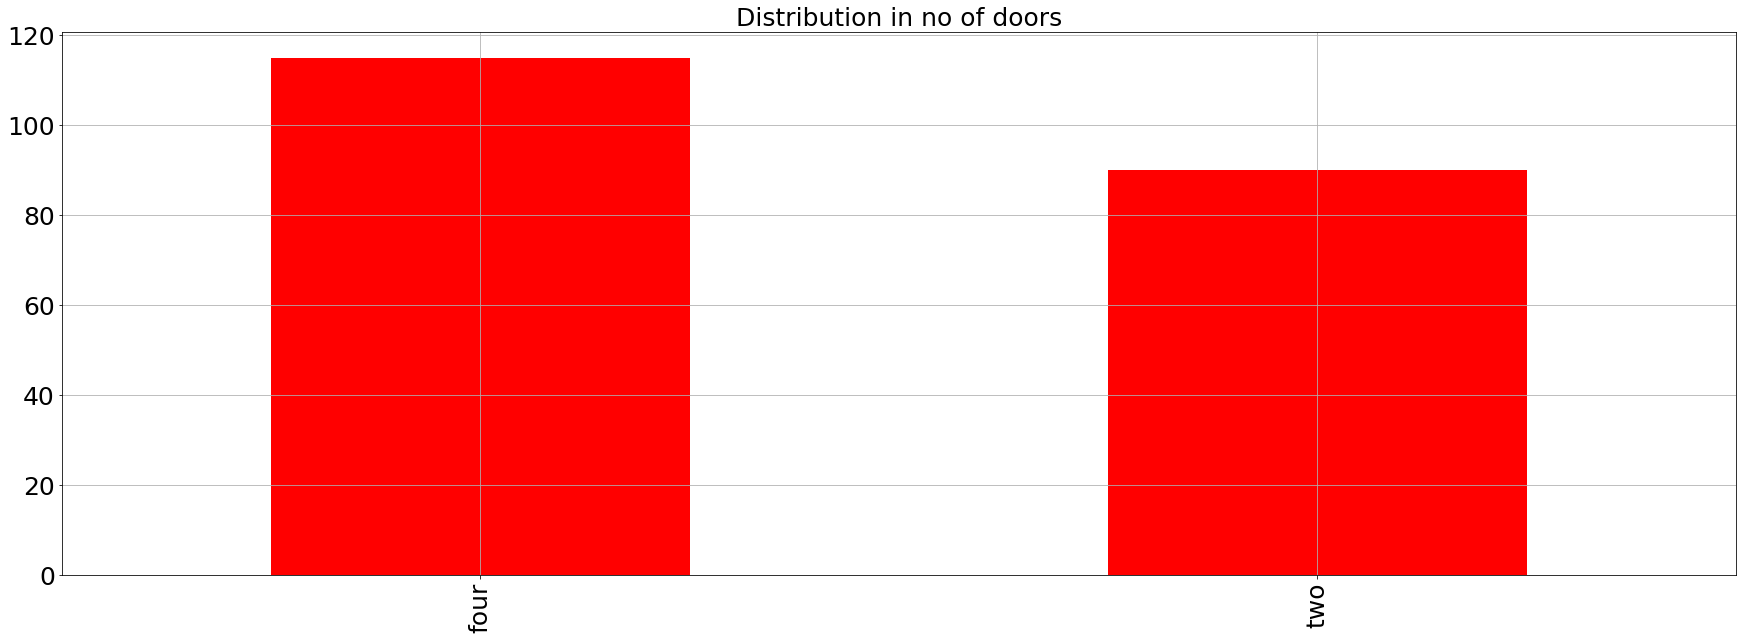

In [16]:
paper = plt.figure(figsize=[30,10])
data['doornumber'].value_counts().plot.bar(color="red")
plt.xticks(size=25)
plt.yticks(size=25)
plt.title(label="Distribution in no of doors",size=25)
plt.grid(visible=True)
plt.show()

Distribution of no of doors and fuel type

In [17]:
data.groupby(by=['doornumber'])['fueltype'].value_counts()

doornumber  fueltype
four        gas         98
            diesel      17
two         gas         87
            diesel       3
Name: fueltype, dtype: int64

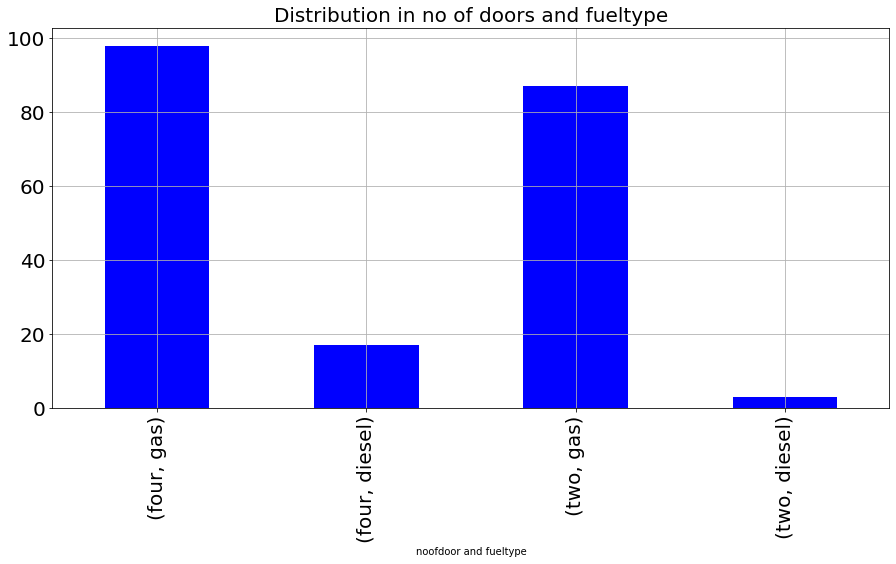

In [18]:
paper = plt.figure(figsize=[15,7])
data.groupby(by=['doornumber'])['fueltype'].value_counts().plot.bar(color='blue')
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel(xlabel="noofdoor and fueltype")
plt.title(label="Distribution in no of doors and fueltype",size=20)
plt.grid(visible=True)
plt.show()

distribution of number of cylinder

In [19]:
data['cylindernumber'].value_counts()

four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: cylindernumber, dtype: int64

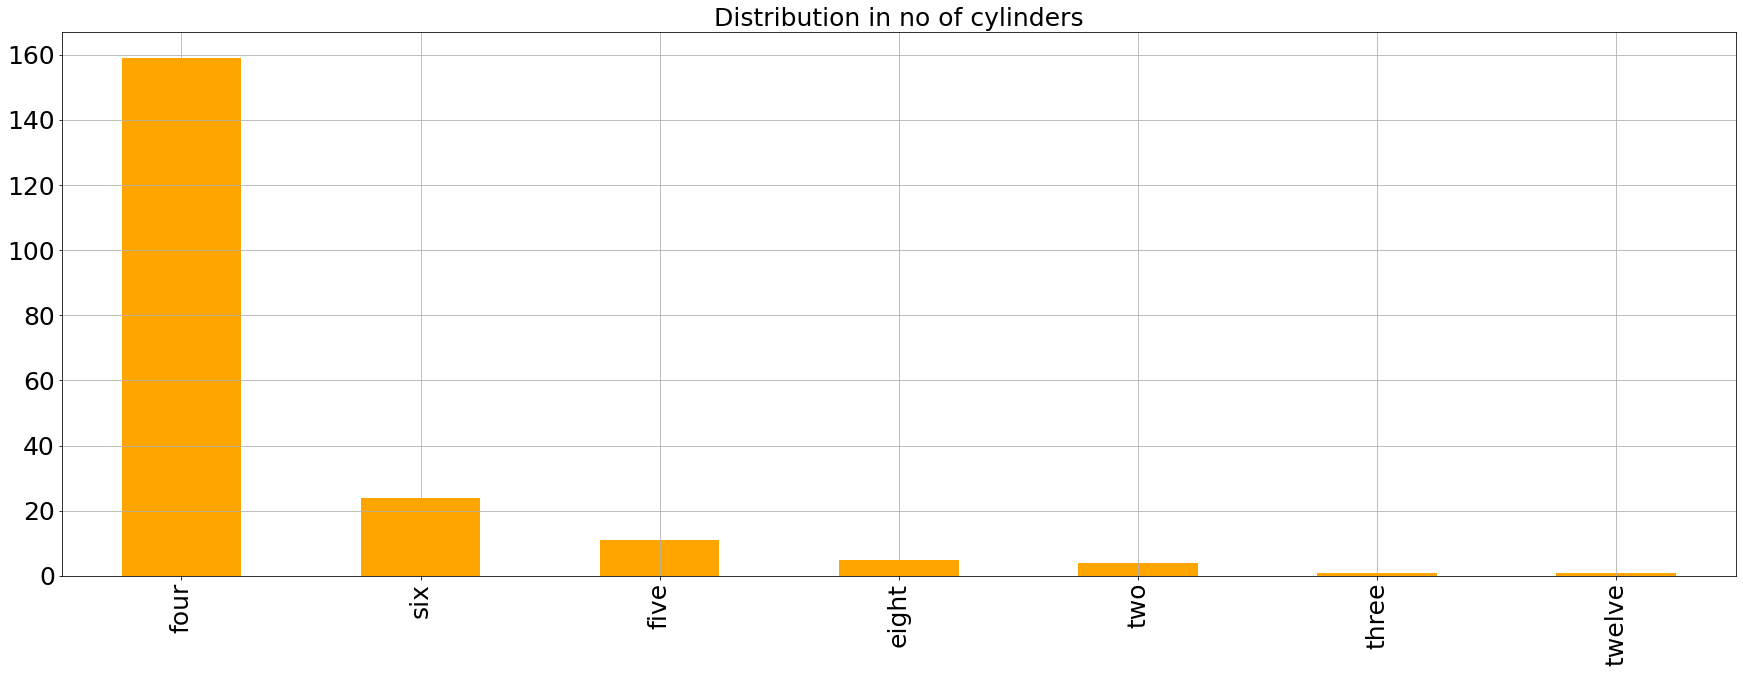

In [20]:
paper = plt.figure(figsize=[30,10])
data['cylindernumber'].value_counts().plot.bar(color="orange")
plt.xticks(size=25)
plt.yticks(size=25)
plt.title(label="Distribution in no of cylinders",size=25)
plt.grid(visible=True)
plt.show()

Distribution of Drive wheels

In [21]:
data['drivewheel'].value_counts()

fwd    120
rwd     76
4wd      9
Name: drivewheel, dtype: int64

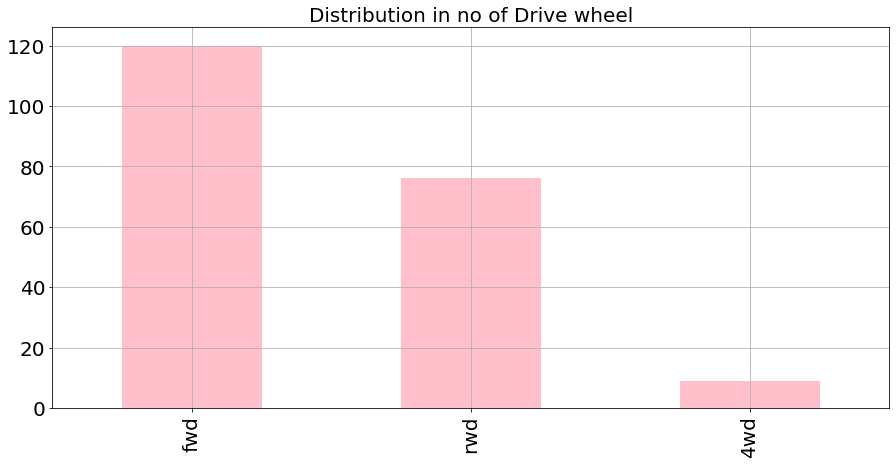

In [22]:
paper = plt.figure(figsize=[15,7])
data['drivewheel'].value_counts().plot.bar(color="pink")
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution in no of Drive wheel",size=20)
plt.grid(visible=True)
plt.show()

Distribution of enginetype 

In [23]:
data['enginetype'].value_counts()

ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: enginetype, dtype: int64

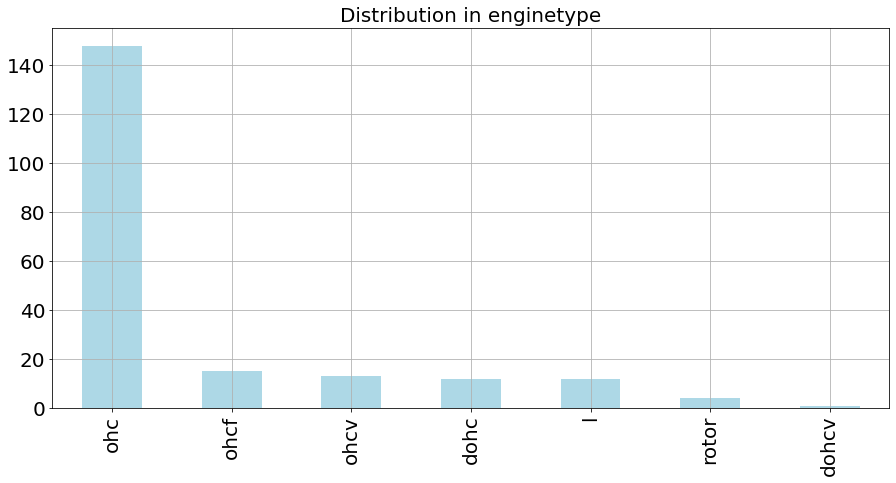

In [24]:
paper = plt.figure(figsize=[15,7])
data['enginetype'].value_counts().plot.bar(color="lightblue")
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution in enginetype",size=20)
plt.grid(visible=True)
plt.show()

In [25]:
data.groupby(by=['enginetype'])['drivewheel'].value_counts()

enginetype  drivewheel
dohc        rwd            10
            fwd             2
dohcv       rwd             1
l           rwd            11
            fwd             1
ohc         fwd           107
            rwd            37
            4wd             4
ohcf        fwd             7
            4wd             5
            rwd             3
ohcv        rwd            10
            fwd             3
rotor       rwd             4
Name: drivewheel, dtype: int64

In [26]:
data.groupby(by=['enginetype'])['drivewheel'].count()

enginetype
dohc      12
dohcv      1
l         12
ohc      148
ohcf      15
ohcv      13
rotor      4
Name: drivewheel, dtype: int64

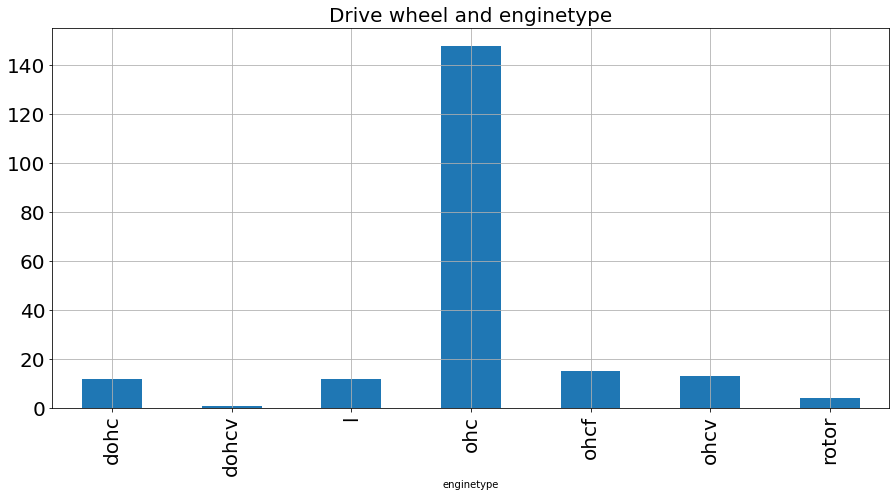

In [27]:
paper = plt.figure(figsize=[15,7])
data.groupby(by=['enginetype'])['drivewheel'].count().plot.bar()
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Drive wheel and enginetype",size=20)
plt.grid(visible=True)
plt.show()

In [28]:
data.groupby(by=['enginetype'])['drivewheel'].count()

enginetype
dohc      12
dohcv      1
l         12
ohc      148
ohcf      15
ohcv      13
rotor      4
Name: drivewheel, dtype: int64

Distribution in symboling

In [29]:
data['symboling'].value_counts()

 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: symboling, dtype: int64

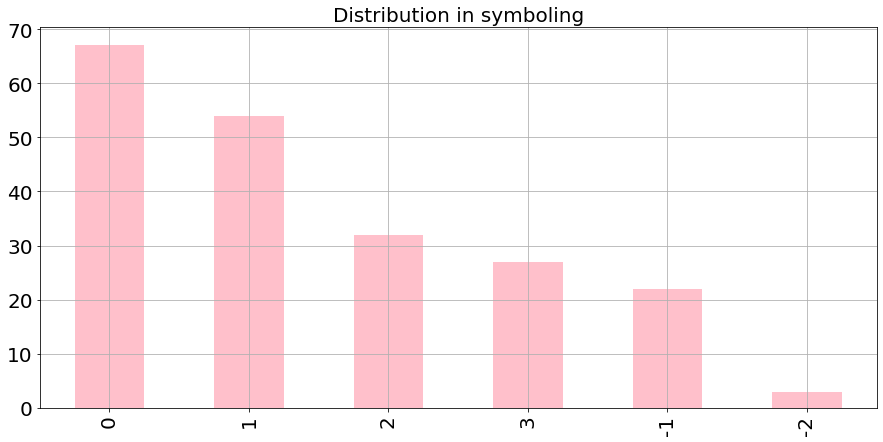

In [30]:
paper = plt.figure(figsize=[15,7])
data['symboling'].value_counts().plot.bar(color="pink")
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution in symboling",size=20)
plt.grid(visible=True)
plt.show()

Distribution in CarBody

In [31]:
data['carbody'].value_counts()

sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: carbody, dtype: int64

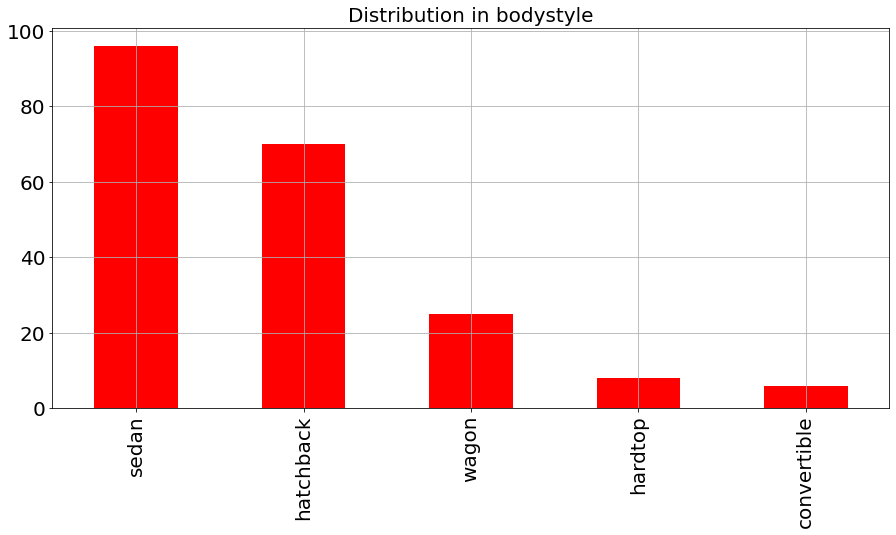

In [32]:
paper = plt.figure(figsize=[15,7])
data['carbody'].value_counts().plot.bar(color="red")
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution in bodystyle",size=20)
plt.grid(visible=True)
plt.show()

In [33]:
sedan_data = data[data["carbody"]=='sedan']
sedan_data.shape

(96, 26)

In [34]:
sedan_data.groupby(by=['symboling']).count()

,car_ID,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
symboling,,,,,,,,,,,,,,,,,,,,,
-2,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
-1,13,13,13,13,13,13,13,13,13,13,...,13,13,13,13,13,13,13,13,13,13
0,43,43,43,43,43,43,43,43,43,43,...,43,43,43,43,43,43,43,43,43,43
1,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
2,14,14,14,14,14,14,14,14,14,14,...,14,14,14,14,14,14,14,14,14,14


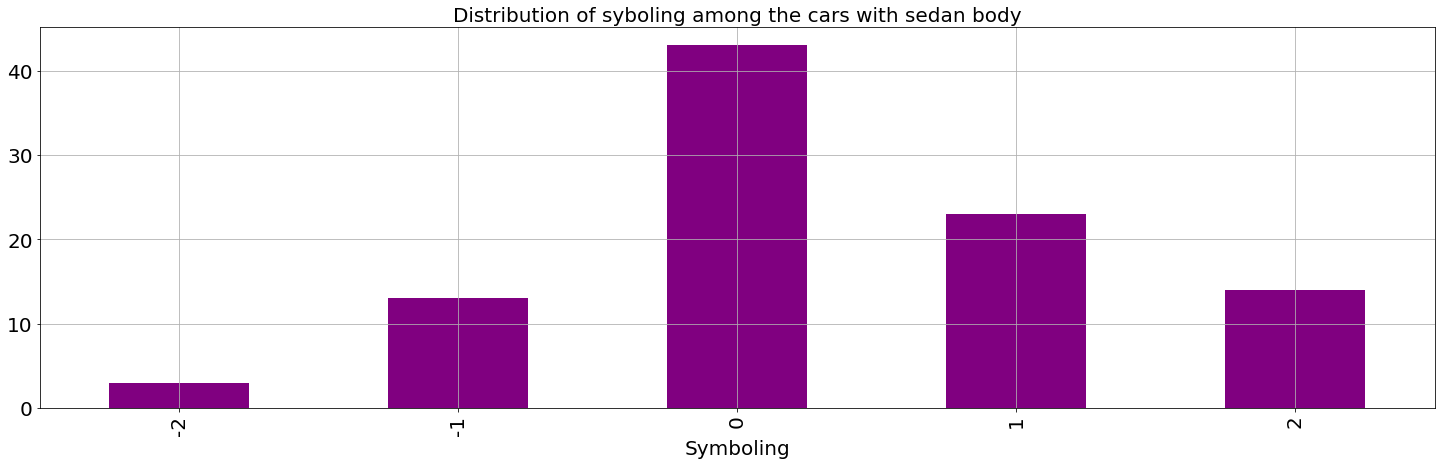

In [35]:
paper = plt.figure(figsize=[25,7])
sedan_data.groupby(by=['symboling'])['doornumber'].count().plot.bar(color='purple')
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel(xlabel="Symboling",size=20)
plt.title(label="Distribution of syboling among the cars with sedan body",size=20)
plt.grid(visible=True)
plt.show()

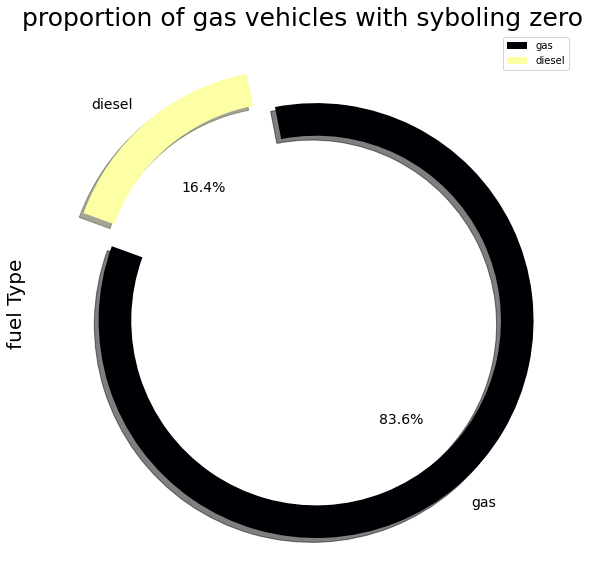

In [36]:
zero_symb_data = data[data['symboling']==0]
paper = plt.figure(figsize=[15,10])
space = np.ones(2)/10
zero_symb_data['fueltype'].value_counts().plot(kind='pie',explode=space,fontsize=14,autopct="%3.1f%%",wedgeprops=dict(width=0.15),shadow=True,startangle=160,cmap='inferno',legend=True)
plt.ylabel(ylabel="fuel Type",size=20)
plt.title(label="proportion of gas vehicles with syboling zero",size=25)
plt.show()

distribution of city Mileage using histogram

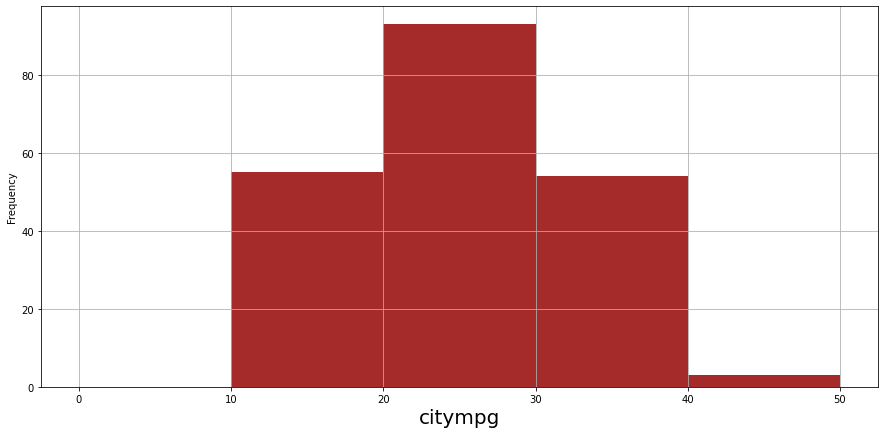

In [37]:
paper=plt.figure(figsize=[15,7])
n=5
bins = np.linspace(0,50,num=6)
data['citympg'].plot.hist(bins=bins,color="brown")
plt.xlabel(xlabel="citympg",size=20)
plt.grid(visible=True)
plt.show()

Distribution of citympg in sedan vehicles

In [38]:
sedan_mpg = sedan_data['citympg']
sedan_mpg[(sedan_mpg>=20)&(sedan_mpg<=30)].value_counts()

24    7
27    7
23    6
26    6
28    5
21    4
30    3
25    3
20    2
22    2
29    2
Name: citympg, dtype: int64

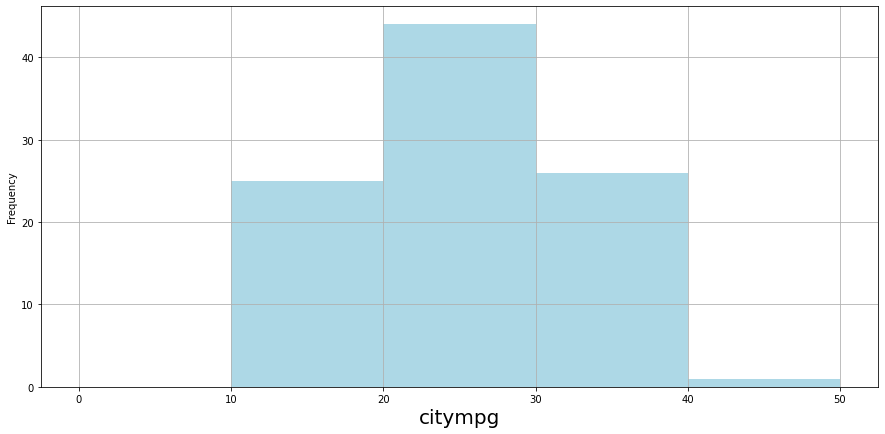

In [39]:
paper=plt.figure(figsize=[15,7])
n=5
bins = np.linspace(0,50,num=6)
sedan_data['citympg'].plot.hist(bins=bins,color="lightblue")
plt.xlabel(xlabel="citympg",size=20)
plt.grid(visible=True)
plt.show()

How many sedan cars has the engine type as ohc?

In [40]:
sedan_ohc = sedan_data[sedan_data['enginetype']=='ohc']
sedan_ohc.shape

(73, 26)

Proportion of no of doors for sedan vehicles

In [41]:
sedan_doors = sedan_data['doornumber']
sedan_doors.value_counts()

four    80
two     16
Name: doornumber, dtype: int64

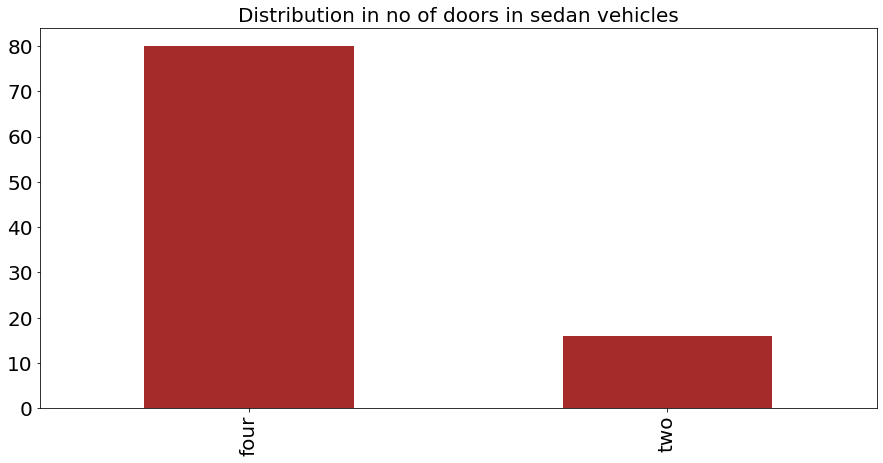

In [42]:
paper = plt.figure(figsize=[15,7])
sedan_doors.value_counts().plot.bar(color="brown")
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution in no of doors in sedan vehicles",size=20)
plt.show()

In [43]:
sedan_ohc['doornumber'].value_counts()

four    59
two     14
Name: doornumber, dtype: int64

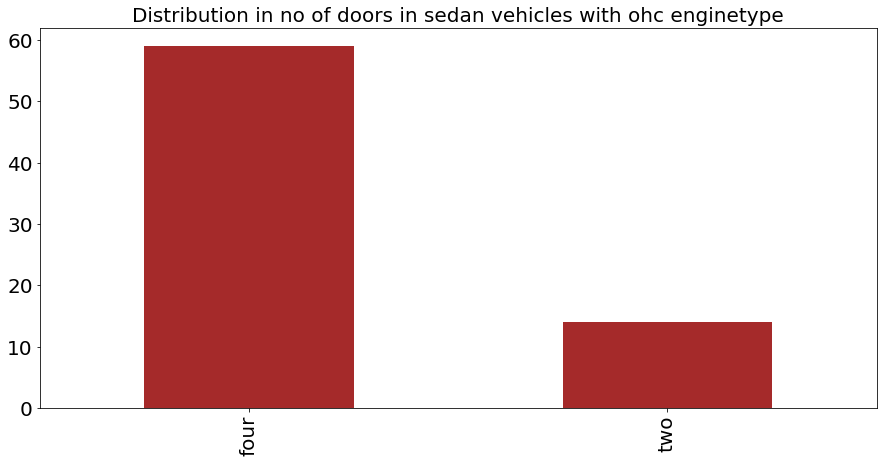

In [44]:
paper = plt.figure(figsize=[15,7])
sedan_ohc['doornumber'].value_counts().plot.bar(color="brown")
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution in no of doors in sedan vehicles with ohc enginetype",size=20)
plt.show()

Distribution of vehicles which has bodyshape of hatchback and there distribution of symboling

In [45]:
hb_data = data[data['carbody']=='hatchback']
hb_data.shape

(70, 26)

In [46]:
hb_data['symboling'].value_counts()

 1    27
 3    20
 2    13
 0     8
-1     2
Name: symboling, dtype: int64

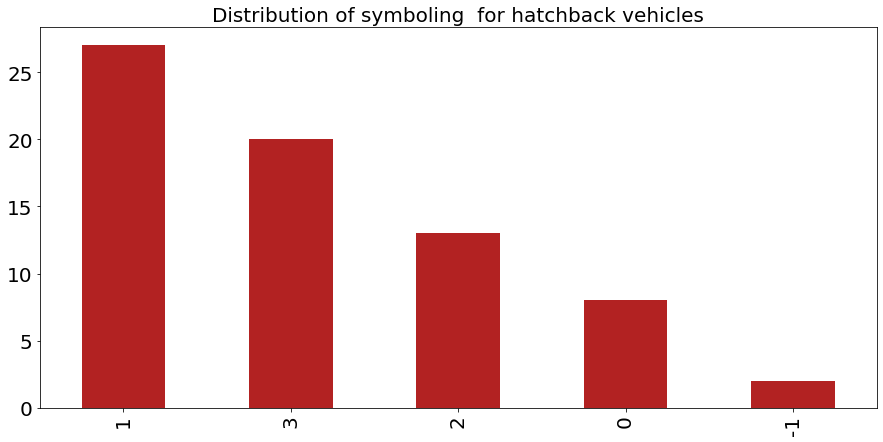

In [47]:
paper = plt.figure(figsize=[15,7])
hb_data['symboling'].value_counts().plot.bar(color='firebrick')
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution of symboling  for hatchback vehicles",size=20)
plt.show()

Distribution in compression ratio for hatchback and sedan vehicles

In [48]:
hb_data['compressionratio'].value_counts()

9.00     16
9.40     13
7.00      6
9.30      5
8.70      5
9.20      4
8.50      3
8.60      3
7.60      3
9.60      2
9.50      2
10.10     1
8.00      1
7.50      1
9.41      1
7.80      1
10.00     1
9.31      1
22.50     1
Name: compressionratio, dtype: int64

In [49]:
hc = hb_data['compressionratio']
hc[hc<10].count()

67

In [50]:
hc[(hc>=10)&(hc<20)].count()

2

In [51]:
hc[(hc>=20)&(hc<30)].count()

1

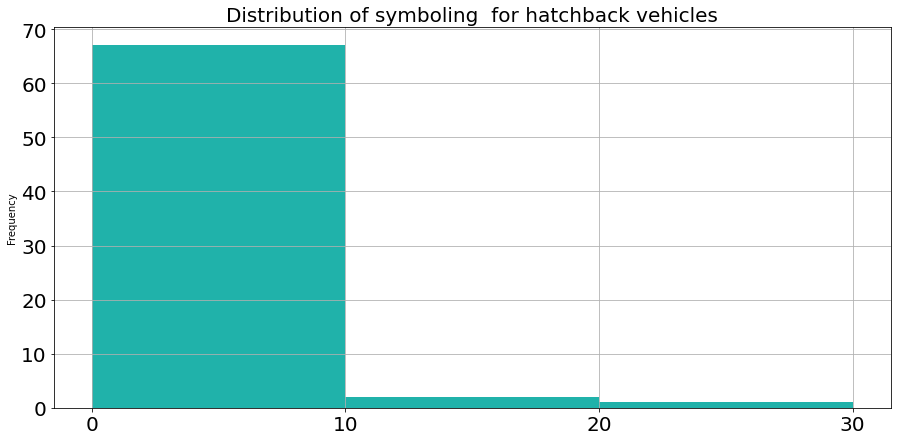

In [52]:
paper = plt.figure(figsize=[15,7])
n = 3
bins = np.linspace(0,30,n+1)
hb_data['compressionratio'].plot.hist(bins=bins,color='lightseagreen')
plt.xticks(ticks=bins,size=20)
plt.yticks(size=20)
plt.title(label="Distribution of symboling  for hatchback vehicles",size=20)
plt.grid(visible=True)
plt.show()

In [53]:
sc = sedan_data['compressionratio']
sc[sc<10].count()

78

In [54]:
sc[(sc>=10)&(sc<20)].count()

3

In [55]:
sc[(sc>=20)&(sc<30)].count()

15

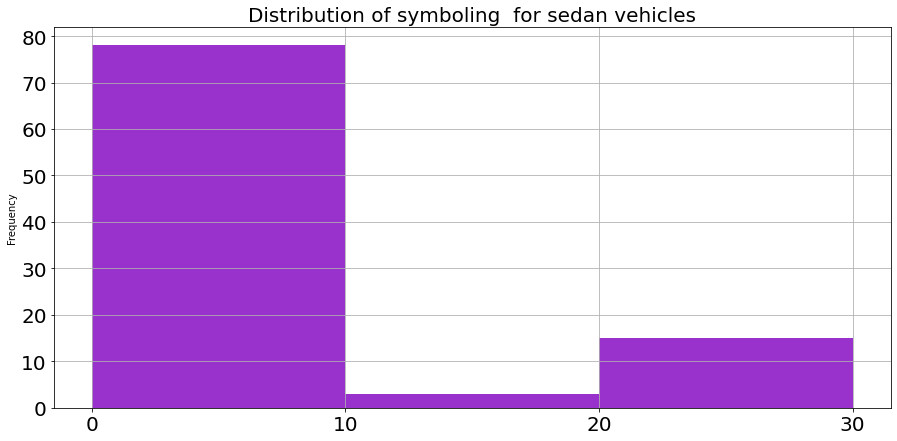

In [56]:
paper = plt.figure(figsize=[15,7])
n = 3
bins = np.linspace(0,30,n+1)
sedan_data['compressionratio'].plot.hist(bins=bins,color='darkorchid')
plt.xticks(ticks=bins,size=20)
plt.yticks(size=20)
plt.title(label="Distribution of symboling  for sedan vehicles",size=20)
plt.grid(visible=True)
plt.show()

Distribution of Fuel System

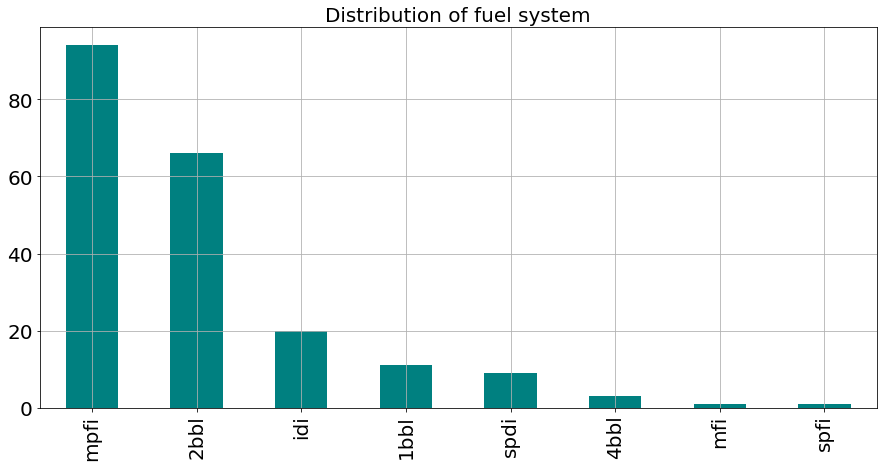

In [57]:
paper = plt.figure(figsize=[15,7])
data['fuelsystem'].value_counts().plot.bar(color='teal')
plt.xticks(size=20)
plt.yticks(size=20)
plt.title(label="Distribution of fuel system",size=20)
plt.grid(visible=True)
plt.show()

In [58]:
data['fuelsystem'].value_counts()

mpfi    94
2bbl    66
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: fuelsystem, dtype: int64

Distribution in horsepower for hatchback and sedan vehicles

In [59]:
shp = sedan_data['horsepower']
shp[shp<100].count()

51

In [60]:
shp[(shp>=100)&(shp<200)].count()

44

In [61]:
shp[(shp>=200)&(shp<300)].count()

1

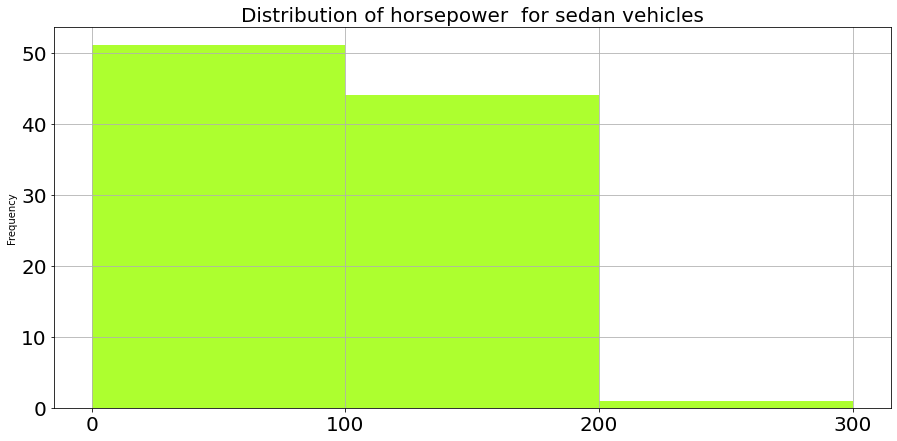

In [62]:
paper = plt.figure(figsize=[15,7])
n = 3
bins = np.linspace(0,300,n+1)
sedan_data['horsepower'].plot.hist(bins=bins,color='greenyellow')
plt.xticks(ticks=bins,size=20)
plt.yticks(size=20)
plt.title(label="Distribution of horsepower  for sedan vehicles",size=20)
plt.grid(visible=True)
plt.show()

In [63]:
hhp = hb_data['horsepower']
hhp[hhp<100].count()

41

In [64]:
hhp[(hhp>=100)&(hhp<200)].count()

27

In [65]:
hhp[(hhp>=200)&(hhp<300)].count()

2

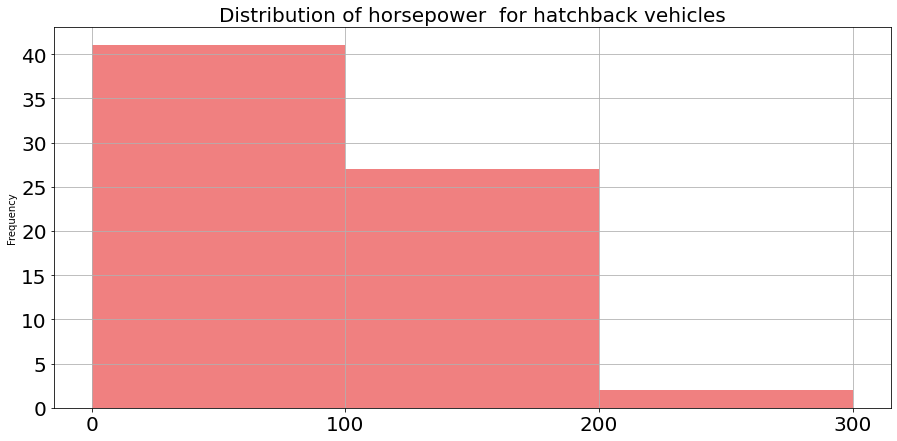

In [66]:
paper = plt.figure(figsize=[15,7])
n = 3
bins = np.linspace(0,300,n+1)
hb_data['horsepower'].plot.hist(bins=bins,color='lightcoral')
plt.xticks(ticks=bins,size=20)
plt.yticks(size=20)
plt.title(label="Distribution of horsepower  for hatchback vehicles",size=20)
plt.grid(visible=True)
plt.show()

## Feature Engineering

Distribution of Car Brands

In [67]:
temp_data= data['CarName'].str.split(" ")

In [68]:
brands = []
for i in temp_data:
  brands.append(i[0])

In [69]:
data['Brands'] = brands

In [70]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price', 'Brands'],
      dtype='object')

In [71]:
data['Brands'].value_counts().head(10)

toyota        31
nissan        17
mazda         15
honda         13
mitsubishi    13
subaru        12
peugeot       11
volvo         11
volkswagen     9
dodge          9
Name: Brands, dtype: int64

In [72]:
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brands
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [73]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price', 'Brands'],
      dtype='object')

In [74]:
data.drop(labels ='car_ID' ,axis = 1,inplace=True)

In [75]:
data.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brands
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [76]:
data['Brands'].value_counts()

toyota         31
nissan         17
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
volkswagen      9
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
alfa-romero     3
chevrolet       3
jaguar          3
vw              2
maxda           2
renault         2
toyouta         1
vokswagen       1
Nissan          1
mercury         1
porcshce        1
Name: Brands, dtype: int64

In [77]:
data.replace(to_replace=['toyouta','Nissan','maxda','vokswagen','vw','porcshce'],value=['toyota','nissan','mazda','volkswagen','volkswagen','porsche'],inplace=True)

In [78]:
data['Brands'].value_counts()

toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
volkswagen     12
subaru         12
peugeot        11
volvo          11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
jaguar          3
chevrolet       3
alfa-romero     3
renault         2
mercury         1
Name: Brands, dtype: int64

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   CarName           205 non-null    object 
 2   fueltype          205 non-null    object 
 3   aspiration        205 non-null    object 
 4   doornumber        205 non-null    object 
 5   carbody           205 non-null    object 
 6   drivewheel        205 non-null    object 
 7   enginelocation    205 non-null    object 
 8   wheelbase         205 non-null    float64
 9   carlength         205 non-null    float64
 10  carwidth          205 non-null    float64
 11  carheight         205 non-null    float64
 12  curbweight        205 non-null    int64  
 13  enginetype        205 non-null    object 
 14  cylindernumber    205 non-null    object 
 15  enginesize        205 non-null    int64  
 16  fuelsystem        205 non-null    object 
 1

Average price of vehicle of each brand:

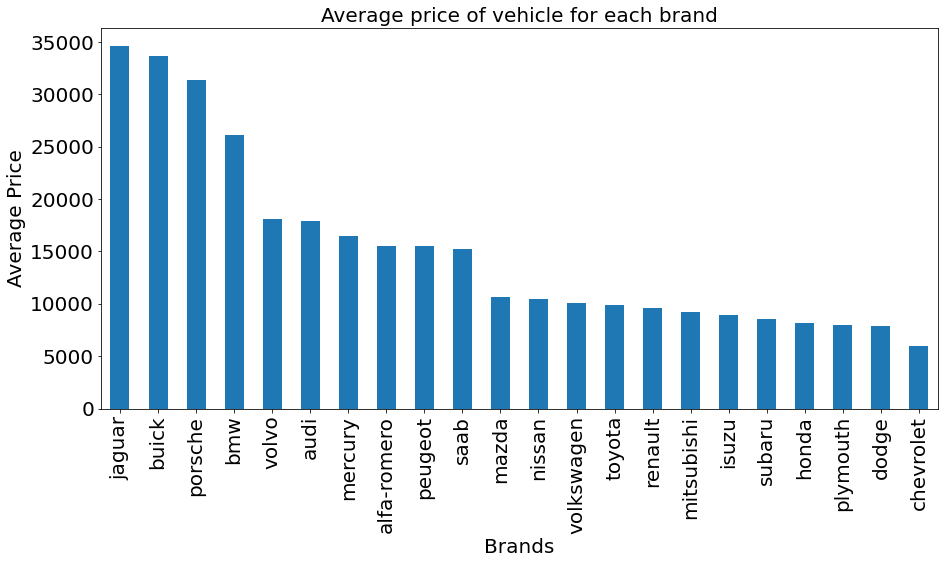

In [80]:
paper = plt.figure(figsize=[15,7])
data.groupby(by='Brands')['price'].mean().sort_values(ascending=False).plot.bar()
plt.xticks(size=20)
plt.yticks(size=20)
plt.xlabel(xlabel="Brands",size=20)
plt.ylabel(ylabel="Average Price",size=20)
plt.title(label="Average price of vehicle for each brand",size=20)
plt.show()

Average price of gas and diesel

In [81]:
data.groupby(by="fueltype")["price"].mean()

fueltype
diesel    15838.1500
gas       12999.7982
Name: price, dtype: float64

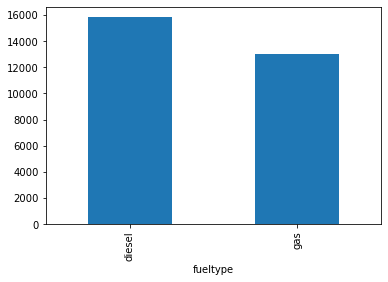

In [82]:
data.groupby(by="fueltype")["price"].mean().plot.bar()
plt.show()

In [83]:
data.groupby(by="fueltype")["price"].median()

fueltype
diesel    13852.5
gas        9989.0
Name: price, dtype: float64

<AxesSubplot:xlabel='fueltype', ylabel='price'>

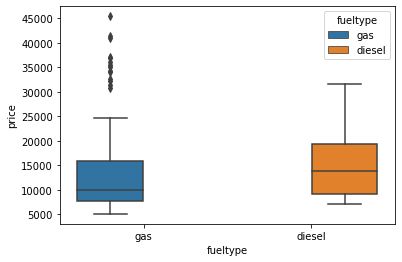

In [84]:
sns.boxplot(data=data, x="fueltype", y="price", hue="fueltype")

In [85]:
data.drop(labels ='CarName' ,axis = 1,inplace=True)

In [86]:
categorical_cols = data.select_dtypes(include='object').columns
categorical_cols

Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem',
       'Brands'],
      dtype='object')

In [87]:
numerical_cols = data.select_dtypes(exclude='object').columns
numerical_cols

Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

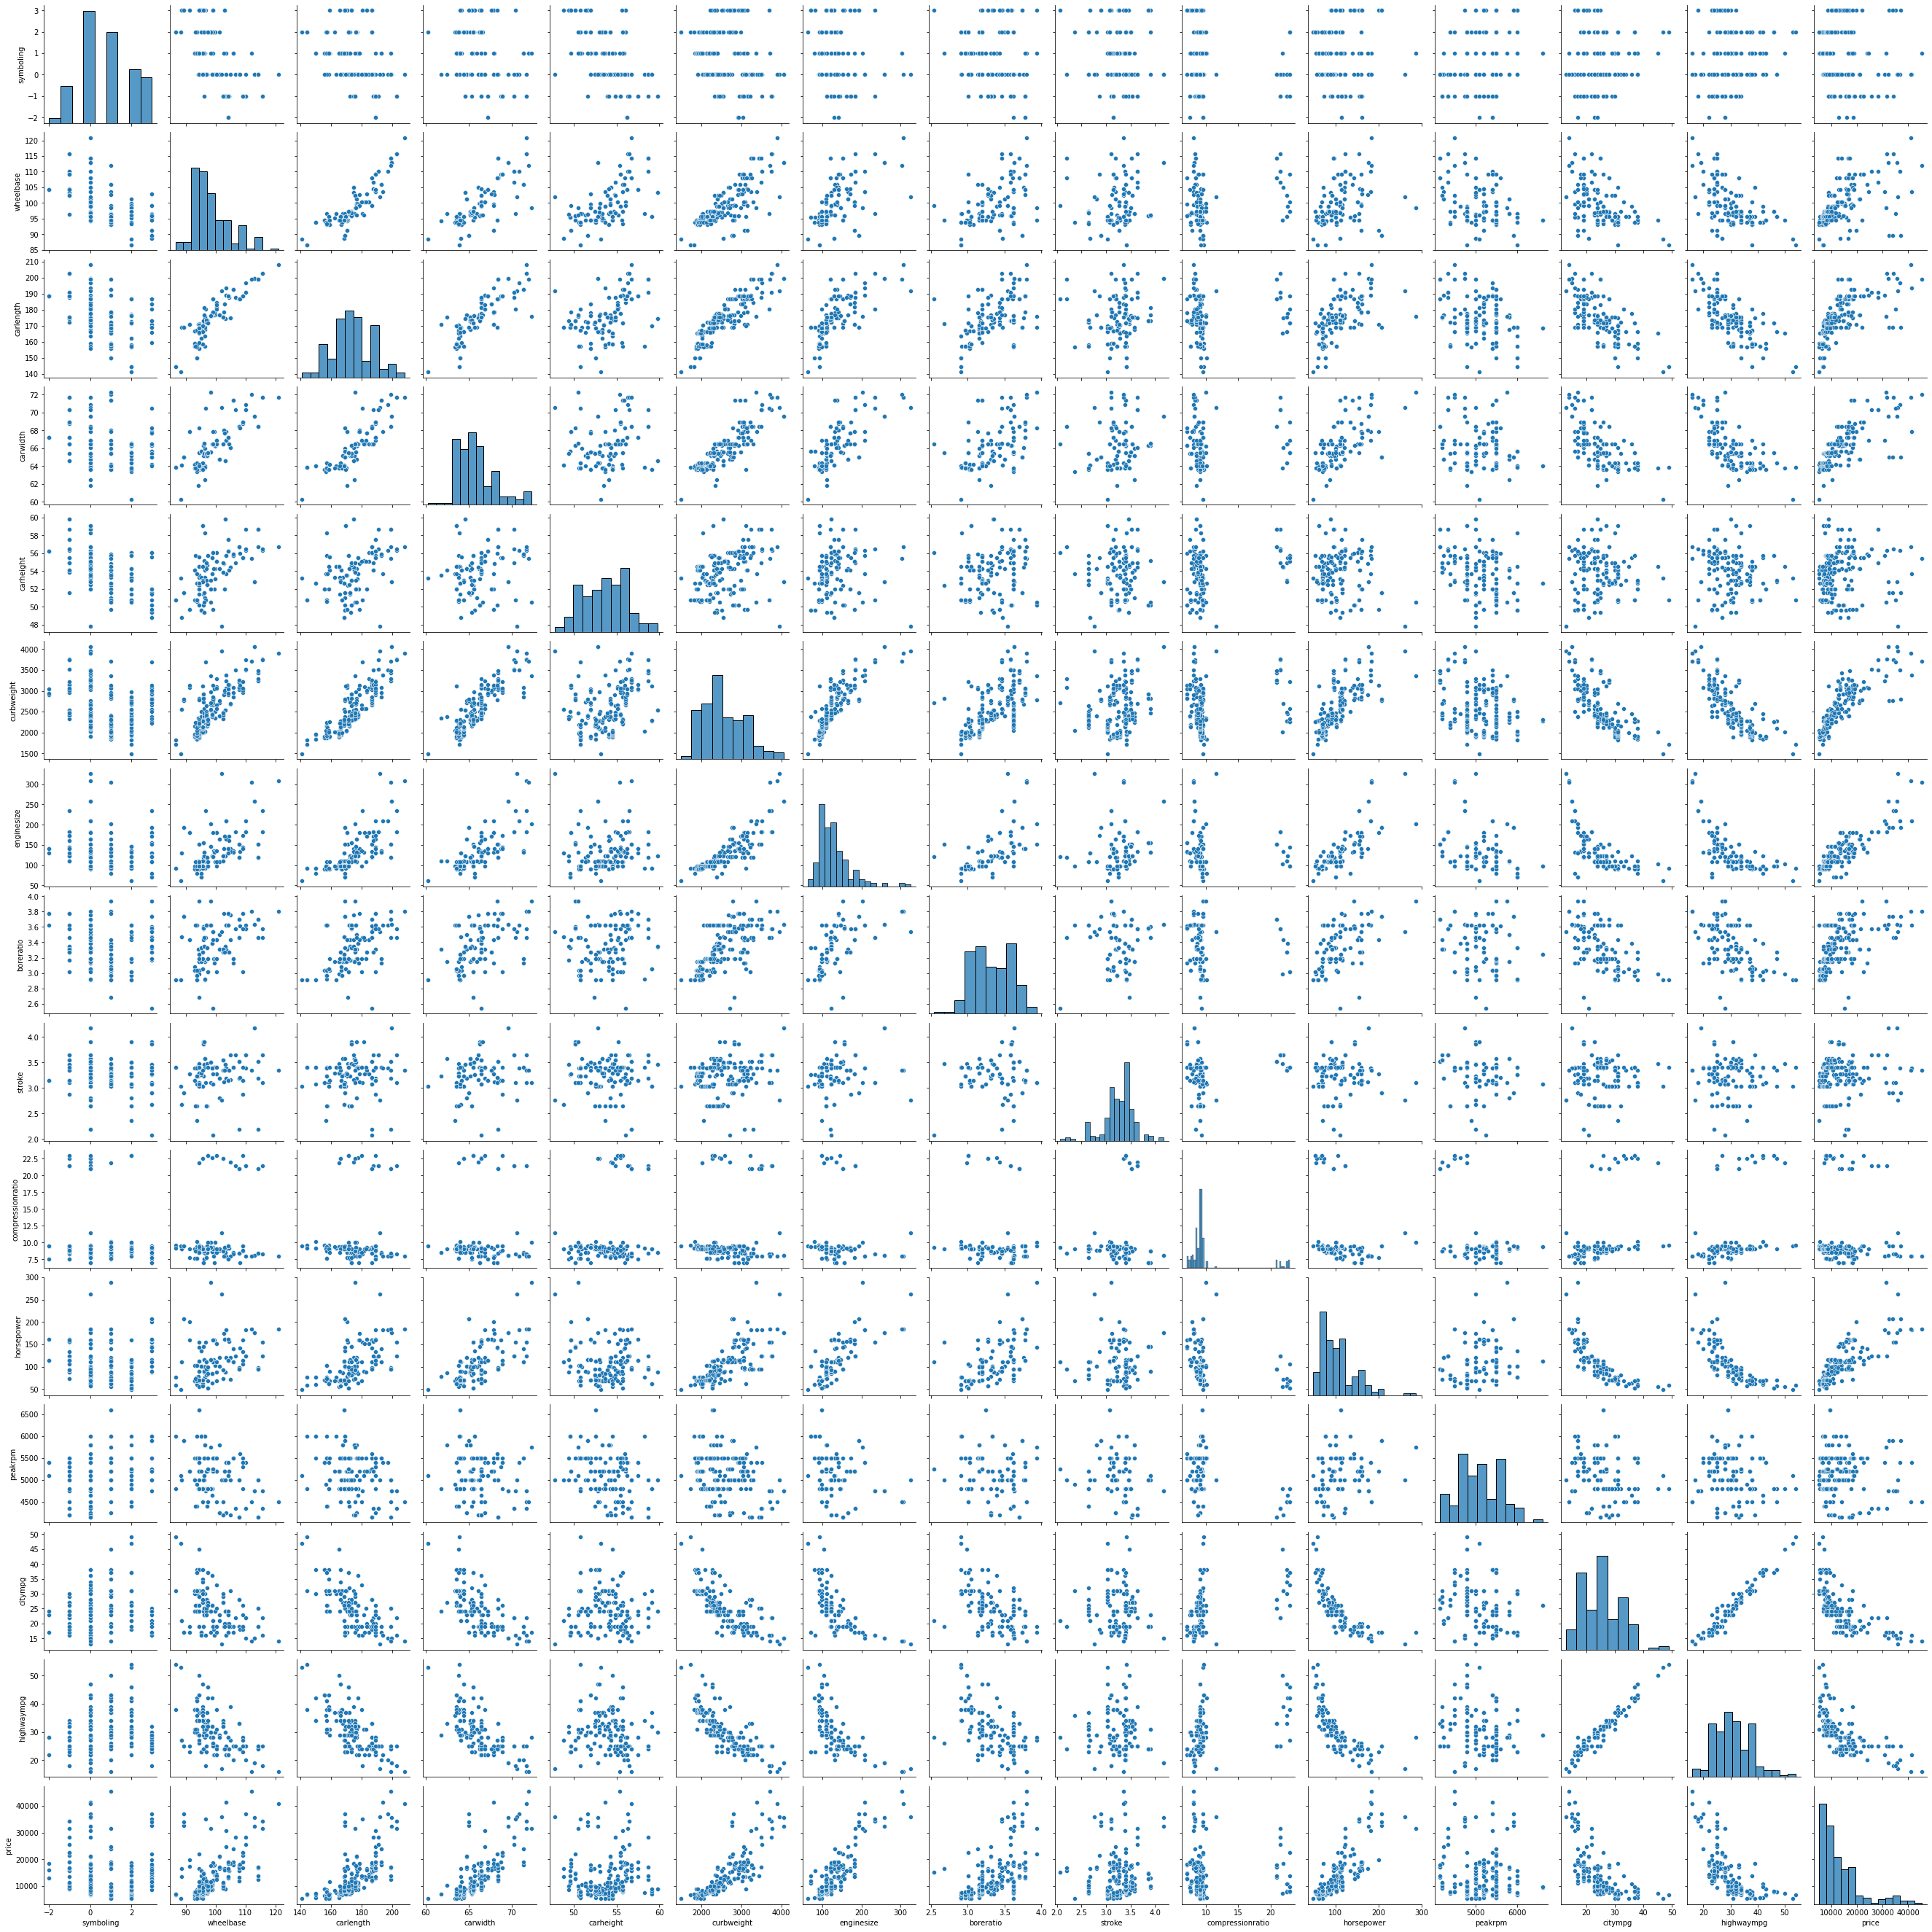

In [88]:
sns.pairplot(data[numerical_cols])

In [89]:
cols = ['wheelbase', 'carlength', 'carwidth', 'carheight','price']

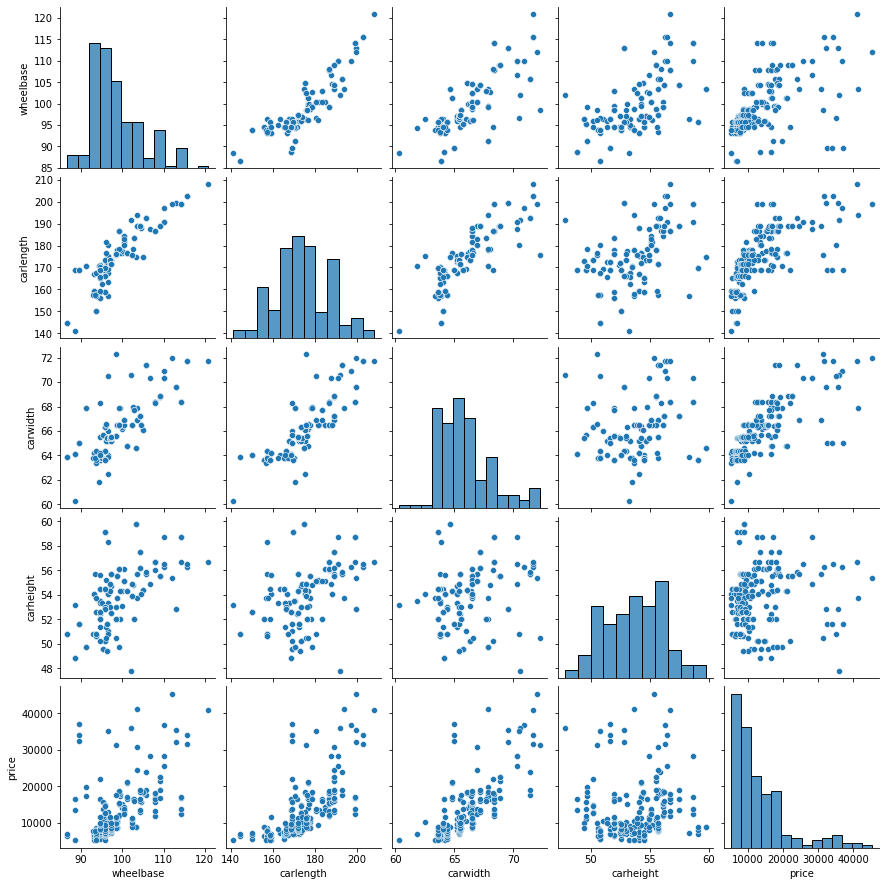

In [90]:
sns.pairplot(data[cols])

In [91]:
all_dummies_df= pd.DataFrame()
for cols in categorical_cols:
  dummy_for_cols = pd.get_dummies(data[cols],prefix=cols)
  all_dummies_df = pd.concat([all_dummies_df,dummy_for_cols],axis=1)

In [92]:
all_dummies_df

,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,doornumber_four,doornumber_two,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,...,Brands_nissan,Brands_peugeot,Brands_plymouth,Brands_porsche,Brands_renault,Brands_saab,Brands_subaru,Brands_toyota,Brands_volkswagen,Brands_volvo
0,0,1,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
201,0,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
202,0,1,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
203,1,0,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [93]:
num_data = data[numerical_cols].copy()
num_data

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,114,5400,23,28,16845.0
201,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,160,5300,19,25,19045.0
202,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,134,5500,18,23,21485.0
203,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,106,4800,26,27,22470.0


In [94]:
model_df = pd.concat([num_data,all_dummies_df],axis=1)
model_df.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,Brands_nissan,Brands_peugeot,Brands_plymouth,Brands_porsche,Brands_renault,Brands_saab,Brands_subaru,Brands_toyota,Brands_volkswagen,Brands_volvo
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,0,0,0,0,0,0,0,0,0,0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,0,0,0,0,0,0,0,0,0,0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,0,0,0,0,0,0,0,0,0,0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,0,0,0,0,0,0,0,0,0,0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
model_df.shape

(205, 75)

In [96]:
X = model_df.drop('price',axis=1)
y = model_df['price']

In [97]:
X.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,Brands_nissan,Brands_peugeot,Brands_plymouth,Brands_porsche,Brands_renault,Brands_saab,Brands_subaru,Brands_toyota,Brands_volkswagen,Brands_volvo
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,0,0,0,0,0,0,0,0,0,0
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,0,0,0,0,0,0,0,0,0,0
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,0,0,0,0,0,0,0,0,0,0
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,0,0,0,0,0,0,0,0,0,0
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,0,0,0,0,0,0,0,0,0,0


In [98]:
y.head()

0    13495.0
1    16500.0
2    16500.0
3    13950.0
4    17450.0
Name: price, dtype: float64

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: (164, 74)
y_train.shape: (164,)
X_test.shape: (41, 74)
y_test.shape: (41,)


In [100]:
## Linear Regression

In [101]:
reg = LinearRegression()
lrm  = reg.fit(X_train,y_train)

In [102]:
lrm.coef_

array([-4.48653866e+02,  2.95112304e+02, -2.14902697e+02,  7.95865745e+02,
       -3.42397756e+02,  8.03792674e+00,  8.85700612e+01, -3.28656987e+03,
       -5.90849798e+02, -9.06208055e+02, -8.92828514e-01,  2.61444232e+00,
        6.53543888e+01,  8.26203286e+01,  3.67780123e+03, -3.67780123e+03,
       -9.62010706e+02,  9.62010706e+02, -7.87713487e+01,  7.87713487e+01,
        1.64840719e+03,  2.14937022e+02, -1.14745046e+03, -3.59666852e+02,
       -3.56226900e+02,  5.10473221e+02, -6.37837152e+02,  1.27363931e+02,
       -4.58146973e+03,  4.58146973e+03, -8.25787556e+02,  2.27373675e-12,
       -2.10855779e+03,  5.52230789e+02,  2.01222346e+03, -2.92611619e+03,
        3.29600729e+03,  2.74932021e+03, -3.86100261e+03, -1.87331296e+02,
       -8.30702182e+02, -5.45696821e-12, -1.16629140e+03,  3.29600729e+03,
       -2.34234259e+03,  9.05157608e+02, -7.69141054e+02,  3.67780123e+03,
        1.36424205e-12, -4.83492683e+02, -1.09757579e+03,  1.09593272e+02,
        2.60132112e+03,  

In [103]:
pred_train = lrm.predict(X_train)
pred_test = lrm.predict(X_test)

In [104]:
pred_train

array([31622.73352035,  6066.4978054 , 22270.0373604 , 18243.84238266,
       13644.91989536,  8806.33918483,  7773.7943644 , 17167.23724591,
        6497.82526953, 42137.5201472 , 17604.34349414,  8309.29886672,
       15669.63962774,  7950.78936668, 12454.71003208, 16130.32920331,
        9108.71364672,  5418.64631466,  8630.81593615,  7059.4122721 ,
        9114.6937074 ,  8414.60618513, 12561.97872277, 10525.75042182,
       33884.43052911,  5941.55481214, 11767.56899955, 23569.72069387,
        6617.44952085,  5803.37793044,  7577.72178343,  6161.9467165 ,
       18792.1301367 ,  6246.5458077 ,  9957.25052582,  9489.30158577,
       18442.71328151,  8930.5368462 , 36000.        ,  9350.70902852,
       36401.00620718,  9700.69841423,  8069.32786918, 18287.10194968,
       33900.        ,  7043.69215952,  9232.34930183,  9651.61430098,
       15197.9889137 , 18056.99180286, 40549.72746231, 27409.73073046,
        9895.58474383,  6200.85724472, 20586.01676224,  6596.60945152,
      

In [105]:
pred_test

array([ 6174.65468747,  6944.99835445,  8659.3609361 ,  8635.47882638,
       13352.69648047,  6715.47237224,  6358.258304  ,  6886.86338204,
       13746.70192995, 11799.72070649,  4998.47353635,  5461.5191274 ,
        9139.95642428, 14305.29102217, 10259.47248984, 11622.19798854,
       13604.81036632, -3001.66475771,  4612.77666383, 12948.64829618,
       14356.23345518,  8011.50960085, 14359.58138307, 33884.43052911,
       15215.75286182,  6177.87052479,  5927.25708084, 14738.30952424,
       11274.63897051, 37424.97382589, 13604.81036632,  8548.03510232,
       10858.4841055 ,  8121.800049  ,  6409.25110607, 23919.96436258,
       15241.76935563, 11835.93247976,  6185.27300652, 14709.36347746,
        9646.34580864])

## Root Mean squared Error

In [106]:
tr_res = mean_squared_error(y_train,pred_train,squared=False)
print(tr_res)

1458.0980060038537


In [107]:
te_res = mean_squared_error(y_test,pred_test,squared=False)
print(te_res)

2481.579860644005


## R squared Error

In [108]:
r2_score(y_train,pred_train)

0.9690747953725367

In [109]:
r2_score(y_test,pred_test)

0.8274598490334062

## Mean Absolute Percentage Error

In [110]:
res = mean_absolute_percentage_error(y_train,pred_train)
res = res*100
print(res)

8.369321176272125


In [111]:
res1 = mean_absolute_percentage_error(y_test,pred_test)
res1 = res1*100
print(res1)

19.259136191930434


In [112]:
print(f"MAPE train Accuracy: {100-res}")
print(f"MAPE test Accuracy: {100-res1}")

MAPE train Accuracy: 91.63067882372788
MAPE test Accuracy: 80.74086380806956


## Decision Trees

In [113]:
dt_model = DecisionTreeRegressor().fit(X_train,y_train)
dt_pred_train = dt_model.predict(X_train)
dt_pred_test = dt_model.predict(X_test)

In [114]:
dt_model.get_depth()

15

## R squared Error

In [115]:
r2_score(y_train,dt_pred_train)

0.9991592502704072

In [116]:
r2_score(y_test,dt_pred_test)

0.7568226941668474

## Mean Absolute Percentage Error

In [117]:
dtres = mean_absolute_percentage_error(y_train,dt_pred_train)
dtres = dtres*100
print(dtres)

0.40035541492418186


In [118]:
dtres1 = mean_absolute_percentage_error(y_test,dt_pred_test)
dtres1 = dtres1*100
print(dtres1)

13.582991792604151


In [119]:
print(f"MAPE train Accuracy: {100-dtres}")
print(f"MAPE test Accuracy: {100-dtres1}")

MAPE train Accuracy: 99.59964458507582
MAPE test Accuracy: 86.41700820739585


## GridSearch CV

In [120]:
param_grid = {'max_depth':[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,100,124,150,1000]}
clf = GridSearchCV(DecisionTreeRegressor(),param_grid,cv=5)
clf.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                       14, 15, 16, 17, 18, 100, 124, 150,
                                       1000]})

In [121]:
bclf = clf.best_estimator_
bclf

DecisionTreeRegressor(max_depth=4)

In [122]:
clf.best_params_

{'max_depth': 4}

In [123]:
new_preds_test = bclf.predict(X_test)

In [124]:
bdtres1 = mean_absolute_percentage_error(y_test,new_preds_test)
bdtres1 = bdtres1*100
print(bdtres1)

21.001057452069624


In [125]:
print(f"MAPE test Accuracy: {100-bdtres1}")

MAPE test Accuracy: 78.99894254793037


## Random Forest

In [126]:
rf_model = RandomForestRegressor().fit(X_train,y_train)
rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)

## R squared Error

In [127]:
r2_score(y_train,rf_pred_train)

0.9891785723389382

In [128]:
r2_score(y_test,rf_pred_test)

0.8886568757263859

## Mean Absolute Percentage Error

In [129]:
rfres = mean_absolute_percentage_error(y_train,rf_pred_train)
rfres = rfres*100
print(rfres)

4.260218997054043


In [130]:
rfres1 = mean_absolute_percentage_error(y_test,rf_pred_test)
rfres1 = rfres1*100
print(rfres1)

12.346656677774233


In [131]:
print(f"MAPE train Accuracy: {100-rfres}")
print(f"MAPE test Accuracy: {100-rfres1}")

MAPE train Accuracy: 95.73978100294596
MAPE test Accuracy: 87.65334332222577


## Random Search CV

In [132]:
param_dist = {
    "max_depth": sp_randint(2,5),
    "min_samples_leaf": sp_randint(1,11),
    "bootstrap": [True,False],
    "n_estimators": [100,200,300,400,500,600,700,1000,1500],
    "max_features": ["sqrt","log2",None]    
}
random_search = RandomizedSearchCV(estimator=rf_model,param_distributions= param_dist ,n_iter= 50,n_jobs= -1)
random_search.fit(X_train,y_train)
brf_pred_train = random_search.predict(X_train)
brf_pred_test =  random_search.predict(X_test)

In [133]:
brf_pred_train

array([33837.09574627,  6906.65436273, 19136.52115825, 17073.89798008,
       16598.77894964,  8088.40493879,  7703.55335648, 15912.72460898,
        7933.41099242, 36280.7924455 , 15548.07690902,  8863.07896624,
       17255.65372911,  8552.54034569, 10976.50095633, 16300.1575315 ,
        7445.31503304,  6796.40050612,  9237.98072198,  7186.19634666,
        9799.2356382 ,  7974.98704288, 15359.18458185, 11124.35161348,
       33498.52777456,  7010.66430977, 10930.35502096, 19062.42085428,
        7341.25607626,  7649.7320579 ,  7798.87782225,  7316.15397993,
       12856.66620528,  6951.6473269 , 10291.48643553, 11060.60855877,
       19783.59516084, 10309.10594446, 35375.91943839, 10328.16748039,
       34895.86028086, 10623.67917459,  8540.1091388 , 18818.03737366,
       34814.02131041,  7017.22039962,  8310.11763313,  8894.21113323,
       15901.60673099, 17237.95717929, 36413.42676368, 31748.19328865,
       10619.62655341,  6873.34361139, 19132.58945549,  7821.08399585,
      

In [134]:
brf_pred_test

array([ 7087.60741504,  7523.81113971,  6927.88148011, 10328.12342013,
       15543.15720305,  7022.01915635,  6886.65199388,  7727.75310505,
       11959.26366264, 10930.35502096,  7658.34602774,  7302.89739508,
        8512.25027455, 16688.94705421,  9116.92003933, 10059.00067829,
       11763.01869628,  6796.40050612,  7038.12555665, 15034.68231782,
       12273.47122449,  9154.18564474, 16598.77894964, 33498.52777456,
       15812.23496167,  7105.0042372 ,  6904.23941792, 16643.85867326,
        9273.97257116, 33916.98003908, 11763.01869628,  7975.21421619,
        9568.89535758,  6980.53319939,  9642.38557328, 17574.60198076,
       17032.94265158, 16105.80623652,  6821.20142266, 15622.54906339,
        8765.1212831 ])

## R squared Error

In [135]:
r2_score(y_train,brf_pred_train)

0.9451073800248615

In [136]:
r2_score(y_test,brf_pred_test)

0.872703031630282

## Mean Absolute Percentage Error

In [137]:
brfres = mean_absolute_percentage_error(y_train,brf_pred_train)
brfres = brfres*100
print(brfres)

9.83029535664523


In [138]:
brfres1 = mean_absolute_percentage_error(y_test,brf_pred_test)
brfres1 = brfres1*100
print(brfres1)

15.339033757339735


In [139]:
print(f"MAPE train Accuracy: {100-brfres}")
print(f"MAPE test Accuracy: {100-brfres1}")

MAPE train Accuracy: 90.16970464335478
MAPE test Accuracy: 84.66096624266027


## Feature Importance

In [148]:
importance = random_search.best_estimator_.feature_importances_
feature_df = (pd.DataFrame(importance*100,index=X_train.columns,columns=['Importance']).sort_values('Importance',ascending=True))

In [150]:
feature_df

,Importance
enginetype_rotor,0.000000
cylindernumber_eight,0.000000
cylindernumber_five,0.000000
cylindernumber_three,0.000000
cylindernumber_twelve,0.000000
...,...
carwidth,0.636383
highwaympg,1.154673
horsepower,2.273845
curbweight,27.453575


<AxesSubplot:>

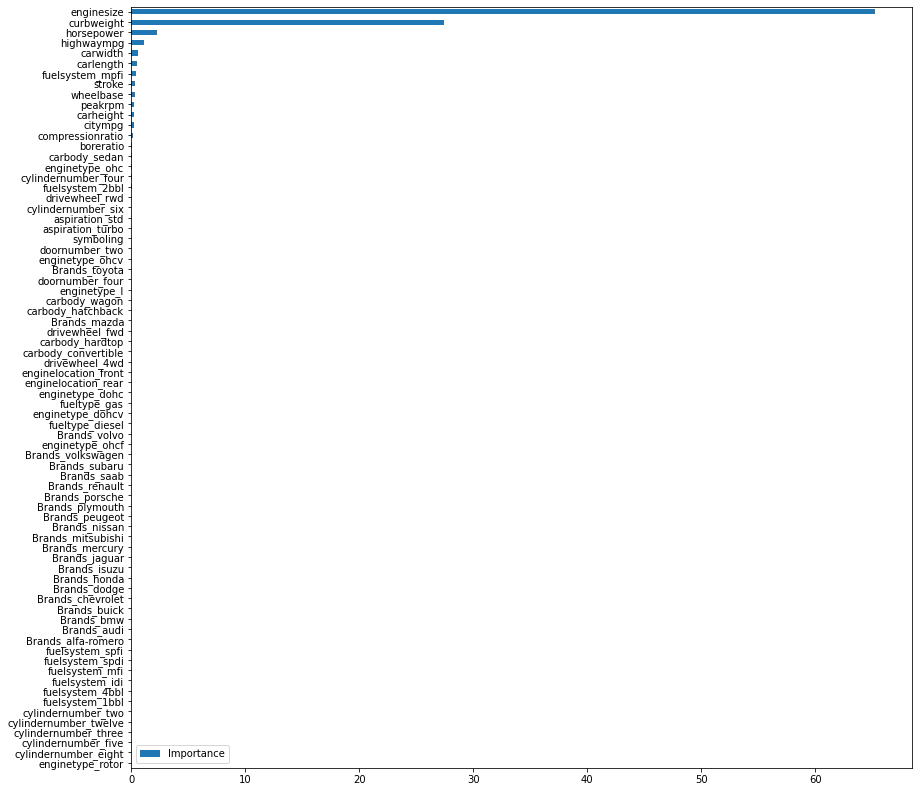

In [151]:
feature_df.plot.barh(figsize=[14,14])